## EDA Analysis of Abalone Dataset Before Production Code


In [4]:
import pandas as pd
import numpy as np

In [19]:
column_names = ["Sex", "Length", "Diameter", "Height", "Whole weight", "Shucked Weight", "Viscera weight", "Shell weight", "Rings"]

df = pd.read_csv("../data/abalone.data", header=None, names=column_names)
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [20]:
df.shape

(4177, 9)

In [21]:
df.dtypes

Sex                   str
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked Weight    float64
Viscera weight    float64
Shell weight      float64
Rings               int64
dtype: object

In [22]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [25]:
print(df.isna().sum())
print(df.duplicated().sum())
numeric_cols = ["Length" ,"Diameter",	"Height",	"Whole weight",	"Shucked Weight",	"Viscera weight",	"Shell weight",	"Rings"]
print((df[numeric_cols] < 0).sum())
df[df["Height"]==0]

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked Weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64
0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked Weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64


,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
1257,I,0.430,0.34,0.0,0.428,0.2065,0.0860,0.1150,8
3996,I,0.315,0.23,0.0,0.134,0.0575,0.0285,0.3505,6


### Drop 0 Height Samples, physically Implausible 

In [26]:
df = df[df["Height"]!=0].reset_index(drop = True)
df.shape

(4175, 9)

## Univariate Behaviour

Matplotlib is building the font cache; this may take a moment.


array([[<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Diameter'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Whole weight'}>,
        <Axes: title={'center': 'Shucked Weight'}>,
        <Axes: title={'center': 'Viscera weight'}>],
       [<Axes: title={'center': 'Shell weight'}>,
        <Axes: title={'center': 'Rings'}>, <Axes: >]], dtype=object)

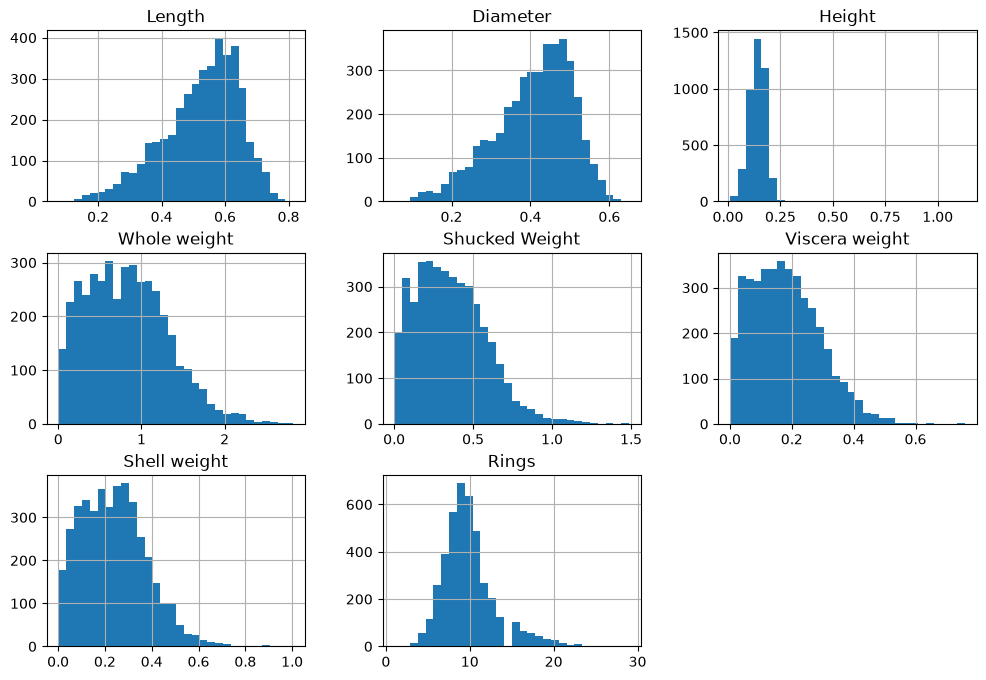

In [28]:
df[column_names].hist(figsize=(12,8), bins=30)

In [29]:
df[numeric_cols].skew()

Length           -0.640993
Diameter         -0.610182
Height            3.166364
Whole weight      0.530549
Shucked Weight    0.718735
Viscera weight    0.591455
Shell weight      0.621081
Rings             1.113754
dtype: float64

### Finding Outliers
Height has extreme outlier on the right side with 1.13

In [32]:
outlier_row = df[df["Height"] == 1.13]
outlier_row

,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
2050,F,0.455,0.355,1.13,0.594,0.332,0.116,0.1335,8


In [39]:
Length =  outlier_row["Length"].values[0]
Diameter = outlier_row["Diameter"].values[0]

similar_points = df[(df["Length"].between(Length - 0.05, Length + 0.05)) & (df["Diameter"].between(Diameter-0.05, Diameter+0.05))]
similar_points.sort_values("Height", ascending=False)

,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
2050,F,0.455,0.355,1.130,0.5940,0.3320,0.1160,0.1335,8
2518,I,0.505,0.390,0.185,0.6125,0.2670,0.1420,0.1720,7
343,F,0.505,0.375,0.180,0.5680,0.2325,0.1495,0.1700,12
792,M,0.470,0.370,0.180,0.5100,0.1915,0.1285,0.1625,9
1269,I,0.470,0.355,0.180,0.4800,0.2055,0.1050,0.1505,8
...,...,...,...,...,...,...,...,...,...
112,I,0.435,0.320,0.080,0.3325,0.1485,0.0635,0.1050,9
2096,M,0.425,0.330,0.080,0.3610,0.1340,0.0825,0.1250,7
2110,I,0.455,0.355,0.080,0.4520,0.2165,0.0995,0.1250,9
724,M,0.465,0.360,0.080,0.4880,0.1910,0.1250,0.1550,11


Similar values of the other samples Diameter and Length are same but height is quite different. Looks like 10X. I take it as an input error. So I change 1.13 to 0.113

In [40]:
df.loc[2050, "Height"] = 0.113
df.loc[2050]

Sex                    F
Length             0.455
Diameter           0.355
Height             0.113
Whole weight       0.594
Shucked Weight     0.332
Viscera weight     0.116
Shell weight      0.1335
Rings                  8
Name: 2050, dtype: object

<Axes: >

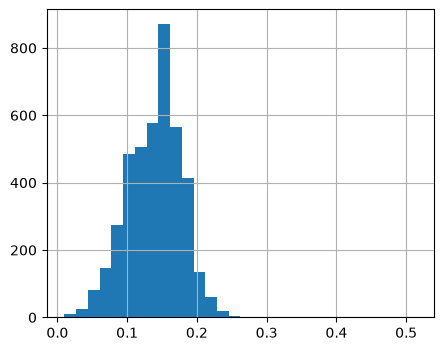

In [42]:
df["Height"].hist(figsize=(5,4), bins=30)

I still see something off here around 0.5, lets look into it. 

In [43]:
df["Height"].max()

np.float64(0.515)

In [44]:
df["Height"].describe()

count    4175.000000
mean        0.139340
std         0.038809
min         0.010000
25%         0.115000
50%         0.140000
75%         0.165000
max         0.515000
Name: Height, dtype: float64

75% of the samples are below 0.165. 0.515 is still quite big. Lets look into it. 

In [45]:
outlier_row_2 = df[df["Height"] == 0.515]
outlier_row_2


,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
1416,M,0.705,0.565,0.515,2.21,1.1075,0.4865,0.512,10


In [49]:
Length_2, Diameter_2 = outlier_row_2["Length"].values[0], outlier_row_2["Diameter"].values[0]

In [52]:
df[(df["Length"].between(Length_2-0.05,Length_2+0.05)) & df["Diameter"].between(Diameter_2-0.05, Diameter_2+0.05)].sort_values("Height", ascending=False)

,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
1416,M,0.705,0.565,0.515,2.2100,1.1075,0.4865,0.5120,10
1527,M,0.725,0.575,0.240,2.2100,1.3510,0.4130,0.5015,13
2160,F,0.715,0.565,0.240,2.1995,0.7245,0.4650,0.8850,17
3992,M,0.720,0.600,0.235,2.2385,0.9840,0.4110,0.6210,12
1426,F,0.750,0.610,0.235,2.5085,1.2320,0.5190,0.6120,14
...,...,...,...,...,...,...,...,...,...
3073,M,0.675,0.520,0.145,1.3645,0.5570,0.3405,0.3850,11
2404,I,0.655,0.515,0.145,1.2500,0.5265,0.2830,0.3150,15
1201,M,0.720,0.565,0.145,1.1870,0.6910,0.1945,0.2685,8
3595,M,0.675,0.515,0.145,1.2650,0.6025,0.2990,0.3250,10


For index 1416, Height is 0.515. More than double the height having same weight and less lenght and diameter seems like an outlier. There is no explanation for this number unlike last one, so I am going to remove this sample to avoid and hurdles in our work. 

In [53]:
df = df[df["Height"] != 0.515].reset_index(drop=True)
df.shape

(4174, 9)

array([[<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Diameter'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Whole weight'}>,
        <Axes: title={'center': 'Shucked Weight'}>,
        <Axes: title={'center': 'Viscera weight'}>],
       [<Axes: title={'center': 'Shell weight'}>,
        <Axes: title={'center': 'Rings'}>, <Axes: >]], dtype=object)

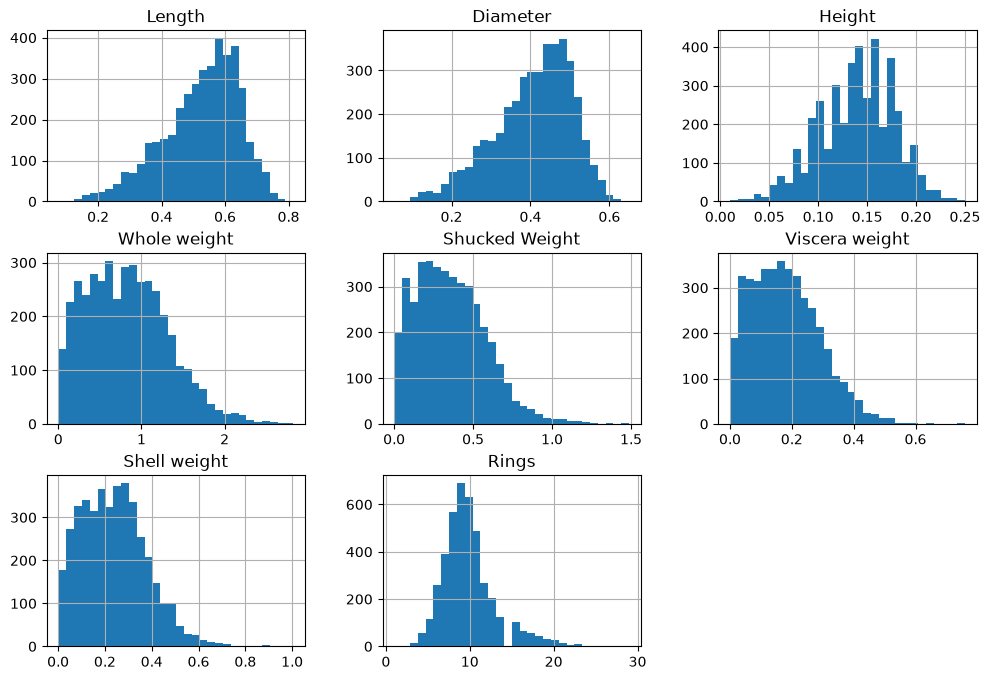

In [57]:
df.hist(figsize=(12,8), bins=30)

In [55]:
df["Height"].describe()

count    4174.000000
mean        0.139250
std         0.038375
min         0.010000
25%         0.115000
50%         0.140000
75%         0.165000
max         0.250000
Name: Height, dtype: float64

Now its balanced and more ready for Z-Score Normalization. Z-Score normlization is more robust here as it more resistant to extreme values. Our Histogram is not mean centered or symmetric in all the features. 

Our weight features are right skewed, in such cases log transformation can help but we will run two models to see if log transformation actually helps or not. 

In [64]:
weight_featrues = ["Whole weight", "Shucked Weight", "Viscera weight", "Shell weight"]
df_weight_logs = df.copy()

for feature in weight_featrues:
    df_weight_logs[feature] = np.log1p(df_weight_logs[feature])

df_weight_logs.head()


,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.414755,0.202533,0.096219,0.139762,15
1,M,0.350,0.265,0.090,0.203349,0.094856,0.047361,0.067659,7
2,F,0.530,0.420,0.135,0.517006,0.228330,0.132343,0.190620,9
3,M,0.440,0.365,0.125,0.416075,0.195156,0.107957,0.144100,10
4,I,0.330,0.255,0.080,0.186480,0.085719,0.038740,0.053541,7


In [73]:
random_state = 42
np.random.default_rng(random_state)

Generator(PCG64) at 0x11A69FE60

## Data Correlation

In [77]:
df.select_dtypes(include=["number"]).corr()

,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
Length,1.000000,0.986795,0.900876,0.925332,0.898109,0.903041,0.898370,0.556609
Diameter,0.986795,1.000000,0.907192,0.925504,0.893314,0.899723,0.906029,0.574583
Height,0.900876,0.907192,1.000000,0.888854,0.837457,0.866769,0.891870,0.610144
Whole weight,0.925332,0.925504,0.888854,1.000000,0.969355,0.966290,0.955949,0.540651
Shucked Weight,0.898109,0.893314,0.837457,0.969355,1.000000,0.931808,0.883154,0.421155
Viscera weight,0.903041,0.899723,0.866769,0.966290,0.931808,1.000000,0.908140,0.504019
Shell weight,0.898370,0.906029,0.891870,0.955949,0.883154,0.908140,1.000000,0.628208
Rings,0.556609,0.574583,0.610144,0.540651,0.421155,0.504019,0.628208,1.000000


## Splitting Data

In [82]:
import numpy as np

def generate_5x2cv_splits(df, n_repetitions=5, random_state=42):
    rng = np.random.default_rng(random_state)

    for rep in range(n_repetitions):
        n = len(df)
        shuffled_idx = rng.permutation(n)
        half = n // 2
        set_A = df.iloc[shuffled_idx[:half]].reset_index(drop=True)
        set_B = df.iloc[shuffled_idx[half:]].reset_index(drop=True)

        yield (rep, 1, set_A, set_B)   
        yield (rep, 2, set_B, set_A)  

In [83]:
splits = generate_5x2cv_splits(df)

rep, fold, train_df, test_df = next(splits)

X_train = train_df.drop(columns=["Rings"]).copy()
y_train = train_df["Rings"].copy()

X_test = test_df.drop(columns=["Rings"]).copy()
y_test = test_df["Rings"].copy()

In [84]:
print("Training:", X_train.shape, y_train.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (2087, 8) (2087,)
Testing: (2087, 8) (2087,)


## Z-Score Normalization

Z-Score normalization is resistant to larger values keeping mean and std at 0 & 1. 

In [86]:
numerical_cols = X_train.select_dtypes(include="number").columns

train_mean = X_train[numerical_cols].mean()
train_std = X_train[numerical_cols].std()

X_train_z_norm = X_train.copy()
X_test_z_norm = X_test.copy()

for x in [X_train_z_norm, X_test_z_norm]:
    x[numerical_cols] = (x[numerical_cols]-train_mean)/train_std

In [87]:
X_train_z_norm.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight
0,M,0.881570,1.074384,0.811618,1.139622,1.241978,1.042469,1.018814
1,M,1.046670,1.074384,1.201264,1.118182,1.757225,-0.001939,0.939814
2,I,-0.851983,-0.820368,-0.357322,-0.889056,-0.909009,-0.710320,-0.884375
3,M,0.675194,0.675489,0.292089,0.659764,0.969730,0.465774,0.422721
4,F,0.922845,0.924798,1.071382,0.990560,0.762731,0.615624,1.772908


In [88]:
X_train.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight
0,M,0.630,0.515,0.170,1.3850,0.6355,0.2955,0.380
1,M,0.650,0.515,0.185,1.3745,0.7500,0.1805,0.369
2,I,0.420,0.325,0.125,0.3915,0.1575,0.1025,0.115
3,M,0.605,0.475,0.150,1.1500,0.5750,0.2320,0.297
4,F,0.635,0.500,0.180,1.3120,0.5290,0.2485,0.485


In [90]:
X_train_ready = pd.get_dummies(X_train_z_norm, columns=["Sex"], dtype=float)
X_test_ready = pd.get_dummies(X_test_z_norm, columns=["Sex"], dtype=float)
X_test_ready = X_test_ready.reindex(columns=X_train_ready.columns, fill_value=0)

In [92]:
X_test_ready.head()

,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Sex_F,Sex_I,Sex_M
0,0.014793,-0.072439,-0.746969,-0.407155,-0.261012,-0.496897,-0.417555,0.0,1.0,0.0
1,-0.521782,-0.620920,-0.487205,-0.840049,-0.726760,-0.837465,-0.941830,0.0,1.0,0.0
2,-2.296610,-2.316224,-2.175674,-1.528186,-1.437755,-1.477732,-1.566651,0.0,1.0,0.0
3,0.633919,0.924798,0.551853,0.384100,0.179985,-0.065511,0.659722,0.0,0.0,1.0
4,0.056068,-0.072439,-0.357322,-0.141702,0.173235,-0.269852,-0.453465,0.0,0.0,1.0


In [93]:
X_train_ready.head()

,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Sex_F,Sex_I,Sex_M
0,0.881570,1.074384,0.811618,1.139622,1.241978,1.042469,1.018814,0.0,0.0,1.0
1,1.046670,1.074384,1.201264,1.118182,1.757225,-0.001939,0.939814,0.0,0.0,1.0
2,-0.851983,-0.820368,-0.357322,-0.889056,-0.909009,-0.710320,-0.884375,0.0,1.0,0.0
3,0.675194,0.675489,0.292089,0.659764,0.969730,0.465774,0.422721,0.0,0.0,1.0
4,0.922845,0.924798,1.071382,0.990560,0.762731,0.615624,1.772908,1.0,0.0,0.0


## Testing for one test sample only


In [94]:
X_train_array = X_train_ready.to_numpy(dtype=float)
X_test_array = X_test_ready.to_numpy(dtype=float)

query = X_test_array[0]

differences = X_train_array - query

distances = np.sqrt(np.sum(differences ** 2, axis=1))

print("First five distances:", distances[:5])
print("Number of distances:", len(distances))

First five distances: [3.94715158 4.08202861 1.54211514 2.89154137 4.02031504]
Number of distances: 2087


## Test for k=3

In [95]:
k = 3

sorted_indices = np.argsort(distances)

nearest_indices = sorted_indices[:k]

# Retrieve those neighbors' distances and target values
nearest_distances = distances[nearest_indices]
nearest_targets = y_train.iloc[nearest_indices].to_numpy()

print("Neighbor row positions:", nearest_indices)
print("Neighbor distances:", nearest_distances)
print("Neighbor Rings:", nearest_targets)

Neighbor row positions: [419  90 131]
Neighbor distances: [0.16815352 0.30806639 0.31597232]
Neighbor Rings: [11  8 10]


## DEcaying Weights

In [96]:
gamma = 1.0

# Calculate a weight for each selected neighbor
weights = np.exp(-gamma * nearest_distances)

# Predict Rings using a weighted average
prediction = np.sum(weights * nearest_targets) / np.sum(weights)

print("Weights:", weights)
print("Predicted Rings:", prediction)

Weights: [0.84522407 0.73486653 0.72907963]
Predicted Rings: 9.729552639621229


## NUll Models

In [101]:
null_results = []

for rep, fold, train_fold, test_fold in generate_5x2cv_splits(df):

    # Targets for this fold
    y_train_fold = train_fold["Rings"].to_numpy(dtype=float)
    y_test_fold = test_fold["Rings"].to_numpy(dtype=float)

    # Predict the training mean for every test sample
    training_mean = y_train_fold.mean()
    null_predictions = np.full(len(y_test_fold), training_mean)

    # Evaluate predictions using mean squared error
    fold_mse = np.mean((y_test_fold - null_predictions) ** 2)

    # Save this fold's result
    null_results.append({
        "repetition": rep + 1,
        "fold": fold,
        "training_mean": training_mean,
        "mse": fold_mse,
    })

null_results_df = pd.DataFrame(null_results)

print(null_results_df.to_string(index=False))
print("\nAverage MSE:", null_results_df["mse"].mean())

 repetition  fold  training_mean       mse
          1     1       9.822233 11.241737
          1     2      10.047916  9.625944
          2     1       9.985146 10.090719
          2     2       9.885002 10.715606
          3     1       9.921897 10.487715
          3     2       9.948251 10.304609
          4     1       9.962626 10.429079
          4     2       9.907523 10.366757
          5     1       9.997125 10.381166
          5     2       9.873023 10.433218

Average MSE: 10.40765493555492


## COmbining everything into one Cell. 

What it does?
1- For each fold, it creates null model, create kNN prediction, find MSE, enter results into our library. 

In [102]:
import numpy as np
import pandas as pd


def knn_regression_predict(X_train, y_train, X_test, k=3, gamma=1.0):

    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    if not isinstance(k, (int, np.integer)) or not 1 <= k <= len(X_train):
        raise ValueError("k must be an integer between 1 and the training size.")

    if not np.isfinite(gamma) or gamma < 0:
        raise ValueError("gamma must be finite and nonnegative.")

    predictions = []

    for query in X_test:

        # Distance to every training sample
        differences = X_train - query
        distances = np.sqrt(np.sum(differences ** 2, axis=1))

        # Select the k nearest neighbors
        nearest_indices = np.argsort(distances, kind="stable")[:k]
        nearest_distances = distances[nearest_indices]
        nearest_targets = y_train[nearest_indices]

        # Numerically stable kernel weights.
        # Subtracting the minimum distance preserves the weighted prediction
        # while preventing every weight from becoming zero.
        weights = np.exp(
            -gamma * (nearest_distances - nearest_distances.min())
        )

        prediction = np.sum(weights * nearest_targets) / np.sum(weights)
        predictions.append(prediction)

    return np.array(predictions)


# Practice parameters: these have NOT been tuned yet
k = 3
gamma = 1.0

results = []

# Start a fresh generator to evaluate all ten folds
for rep, fold, train_fold, test_fold in generate_5x2cv_splits(
    df,
    n_repetitions=5,
    random_state=42
):

    # 1. Separate inputs and targets for THIS fold
    X_train_fold = train_fold.drop(columns=["Rings"]).copy()
    X_test_fold = test_fold.drop(columns=["Rings"]).copy()

    y_train_fold = train_fold["Rings"].to_numpy(dtype=float)
    y_test_fold = test_fold["Rings"].to_numpy(dtype=float)

    # 2. Calculate normalization statistics from training inputs ONLY
    numerical_cols = X_train_fold.select_dtypes(
        include="number"
    ).columns

    train_mean = X_train_fold[numerical_cols].mean()
    train_std = (
        X_train_fold[numerical_cols]
        .std(ddof=0)
        .replace(0, 1)
    )

    # 3. Normalize both halves using the same training statistics
    for X_fold in [X_train_fold, X_test_fold]:
        X_fold[numerical_cols] = (
            X_fold[numerical_cols] - train_mean
        ) / train_std

    # 4. One-hot encode Sex.
    # These three categories come from the known Abalone data schema.
    for X_fold in [X_train_fold, X_test_fold]:
        X_fold["Sex"] = pd.Categorical(
            X_fold["Sex"],
            categories=["F", "I", "M"]
        )

    X_train_ready_fold = pd.get_dummies(
        X_train_fold, columns=["Sex"], dtype=float
    )

    X_test_ready_fold = pd.get_dummies(
        X_test_fold, columns=["Sex"], dtype=float
    )

    # Ensure identical feature columns and order
    X_test_ready_fold = X_test_ready_fold.reindex(
        columns=X_train_ready_fold.columns,
        fill_value=0
    )

    # 5. Convert prepared inputs to NumPy arrays
    X_train_array_fold = X_train_ready_fold.to_numpy(dtype=float)
    X_test_array_fold = X_test_ready_fold.to_numpy(dtype=float)

    # 6. Predict EVERY test sample with kNN
    knn_predictions_fold = knn_regression_predict(
        X_train_array_fold,
        y_train_fold,
        X_test_array_fold,
        k=k,
        gamma=gamma
    )

    knn_mse_fold = np.mean(
        (y_test_fold - knn_predictions_fold) ** 2
    )

    # 7. Evaluate the null model on the SAME fold
    null_predictions_fold = np.full(
        len(y_test_fold),
        y_train_fold.mean()
    )

    null_mse_fold = np.mean(
        (y_test_fold - null_predictions_fold) ** 2
    )

    # 8. Save this fold's results
    results.append({
        "repetition": rep + 1,
        "fold": fold,
        "train_n": len(y_train_fold),
        "test_n": len(y_test_fold),
        "k": k,
        "gamma": gamma,
        "null_mse": null_mse_fold,
        "knn_mse": knn_mse_fold,
    })

    print(f"Completed repetition {rep + 1}, fold {fold}")


# Table containing all ten evaluations
knn_cv_results_df = pd.DataFrame(results)

assert len(knn_cv_results_df) == 10

print("\nRESULTS FOR ALL TEN FOLDS")
print(knn_cv_results_df.round(4).to_string(index=False))


# Summary table
summary_df = pd.DataFrame({
    "model": ["Null", "kNN"],
    "mean_mse": [
        knn_cv_results_df["null_mse"].mean(),
        knn_cv_results_df["knn_mse"].mean(),
    ],
    "std_fold_mse": [
        knn_cv_results_df["null_mse"].std(ddof=1),
        knn_cv_results_df["knn_mse"].std(ddof=1),
    ],
})

print("\nSUMMARY")
print(summary_df.round(4).to_string(index=False))

Completed repetition 1, fold 1
Completed repetition 1, fold 2
Completed repetition 2, fold 1
Completed repetition 2, fold 2
Completed repetition 3, fold 1
Completed repetition 3, fold 2
Completed repetition 4, fold 1
Completed repetition 4, fold 2
Completed repetition 5, fold 1
Completed repetition 5, fold 2

RESULTS FOR ALL TEN FOLDS
 repetition  fold  train_n  test_n  k  gamma  null_mse  knn_mse
          1     1     2087    2087  3    1.0   11.2417   6.2288
          1     2     2087    2087  3    1.0    9.6259   5.5294
          2     1     2087    2087  3    1.0   10.0907   5.9505
          2     2     2087    2087  3    1.0   10.7156   5.8153
          3     1     2087    2087  3    1.0   10.4877   6.0466
          3     2     2087    2087  3    1.0   10.3046   5.8958
          4     1     2087    2087  3    1.0   10.4291   5.8840
          4     2     2087    2087  3    1.0   10.3668   6.0186
          5     1     2087    2087  3    1.0   10.3812   5.8021
          5     2     2

In [105]:
import numpy as np
import pandas as pd


# Prepare inputs using statistics from the supplied training data ONLY
def prepare_features(training_df, other_df):

    X_train = training_df.drop(columns=["Rings"]).copy()
    X_other = other_df.drop(columns=["Rings"]).copy()

    numerical_cols = X_train.select_dtypes(include="number").columns

    # Learn normalization statistics from training inputs
    train_mean = X_train[numerical_cols].mean()
    train_std = (
        X_train[numerical_cols]
        .std(ddof=0)
        .replace(0, 1)
    )

    # Apply those same statistics to both sets
    for X in [X_train, X_other]:
        X[numerical_cols] = (
            X[numerical_cols] - train_mean
        ) / train_std

        # Categories specified by the Abalone dataset
        X["Sex"] = pd.Categorical(
            X["Sex"],
            categories=["F", "I", "M"]
        )

    X_train = pd.get_dummies(
        X_train, columns=["Sex"], dtype=float
    )

    X_other = pd.get_dummies(
        X_other, columns=["Sex"], dtype=float
    )

    X_other = X_other.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    return (
        X_train.to_numpy(dtype=float),
        X_other.to_numpy(dtype=float)
    )


# Candidate values chosen BEFORE looking at test results
k_candidates = list(range(1, 25))

# 25 positive values from 0.001 through 100, spaced logarithmically
gamma_candidates = np.logspace(-3, 2, 25).tolist()


cv_results = []
tuning_results = []


# OUTER LOOP: all ten train/test folds
for rep, fold, train_fold, test_fold in generate_5x2cv_splits(
    df,
    n_repetitions=5,
    random_state=42
):

    # --------------------------------------------------
    # 1. Split ONLY the training half for parameter tuning
    # --------------------------------------------------
    inner_seed = 42 + rep * 2 + fold
    rng = np.random.default_rng(inner_seed)

    shuffled_positions = rng.permutation(len(train_fold))
    split_position = int(0.8 * len(train_fold))

    inner_train = train_fold.iloc[
        shuffled_positions[:split_position]
    ].copy()

    validation = train_fold.iloc[
        shuffled_positions[split_position:]
    ].copy()

    # Fit scaling on inner training; apply it to validation
    X_inner_train, X_validation = prepare_features(
        inner_train,
        validation
    )

    y_inner_train = inner_train["Rings"].to_numpy(dtype=float)
    y_validation = validation["Rings"].to_numpy(dtype=float)

    # --------------------------------------------------
    # 2. Try every k/gamma combination on validation
    # --------------------------------------------------
    best_validation_mse = np.inf
    best_k = None
    best_gamma = None

    for k in k_candidates:

        if k > len(inner_train):
            continue

        for gamma in gamma_candidates:

            validation_predictions = knn_regression_predict(
                X_inner_train,
                y_inner_train,
                X_validation,
                k=k,
                gamma=gamma
            )

            validation_mse = np.mean(
                (y_validation - validation_predictions) ** 2
            )

            # Record every candidate's validation score
            tuning_results.append({
                "repetition": rep + 1,
                "fold": fold,
                "k": k,
                "gamma": gamma,
                "validation_mse": validation_mse
            })

            # Keep the best combination.
            # Exact ties keep the first combination encountered.
            if validation_mse < best_validation_mse:
                best_validation_mse = validation_mse
                best_k = k
                best_gamma = gamma

    if best_k is None:
        raise ValueError("No valid parameter combination was found.")

    # --------------------------------------------------
    # 3. Refit preprocessing on the FULL training half
    # --------------------------------------------------
    # The inner training and validation samples are both
    # already contained in train_fold.
    X_full_train, X_outer_test = prepare_features(
        train_fold,
        test_fold
    )

    y_full_train = train_fold["Rings"].to_numpy(dtype=float)
    y_outer_test = test_fold["Rings"].to_numpy(dtype=float)

    # --------------------------------------------------
    # 4. Evaluate the selected model on the outer test half
    # --------------------------------------------------
    test_predictions = knn_regression_predict(
        X_full_train,
        y_full_train,
        X_outer_test,
        k=best_k,
        gamma=best_gamma
    )

    test_mse = np.mean(
        (y_outer_test - test_predictions) ** 2
    )

    # Null baseline evaluated on the SAME test half
    null_predictions = np.full(
        len(y_outer_test),
        y_full_train.mean()
    )

    null_mse = np.mean(
        (y_outer_test - null_predictions) ** 2
    )

    # --------------------------------------------------
    # 5. Save this fold's final results
    # --------------------------------------------------
    cv_results.append({
        "repetition": rep + 1,
        "fold": fold,
        "inner_train_n": len(inner_train),
        "validation_n": len(validation),
        "full_train_n": len(train_fold),
        "test_n": len(test_fold),
        "best_k": best_k,
        "best_gamma": best_gamma,
        "validation_mse": best_validation_mse,
        "knn_test_mse": test_mse,
        "null_test_mse": null_mse
    })

    print(
        f"Repetition {rep + 1}, fold {fold}: "
        f"k={best_k}, gamma={best_gamma}, "
        f"test MSE={test_mse:.4f}"
    )


# --------------------------------------------------
# 6. Results tables
# --------------------------------------------------
cv_results_df = pd.DataFrame(cv_results)
tuning_results_df = pd.DataFrame(tuning_results)

assert len(cv_results_df) == 10

print("\nSELECTED PARAMETERS AND SCORES FOR ALL TEN FOLDS")
print(cv_results_df.round(4).to_string(index=False))

summary_df = pd.DataFrame({
    "model": ["Null", "Tuned kNN"],
    "mean_test_mse": [
        cv_results_df["null_test_mse"].mean(),
        cv_results_df["knn_test_mse"].mean()
    ],
    "std_fold_mse": [
        cv_results_df["null_test_mse"].std(ddof=1),
        cv_results_df["knn_test_mse"].std(ddof=1)
    ]
})

print("\nFINAL SUMMARY")
print(summary_df.round(4).to_string(index=False))

Repetition 1, fold 1: k=23, gamma=5.623413251903491, test MSE=5.5884
Repetition 1, fold 2: k=15, gamma=2.1544346900318843, test MSE=4.5005
Repetition 2, fold 1: k=10, gamma=5.623413251903491, test MSE=5.2349
Repetition 2, fold 2: k=15, gamma=5.623413251903491, test MSE=5.0964
Repetition 3, fold 1: k=20, gamma=3.4807005884284132, test MSE=5.0809
Repetition 3, fold 2: k=23, gamma=3.4807005884284132, test MSE=5.0934
Repetition 4, fold 1: k=16, gamma=3.4807005884284132, test MSE=5.0436
Repetition 4, fold 2: k=16, gamma=1.333521432163324, test MSE=5.1295
Repetition 5, fold 1: k=14, gamma=3.4807005884284132, test MSE=5.0820
Repetition 5, fold 2: k=19, gamma=2.1544346900318843, test MSE=5.1834

SELECTED PARAMETERS AND SCORES FOR ALL TEN FOLDS
 repetition  fold  inner_train_n  validation_n  full_train_n  test_n  best_k  best_gamma  validation_mse  knn_test_mse  null_test_mse
          1     1           1669           418          2087    2087      23      5.6234          4.4626        5.5884  

## Edited and Condensed kNN along with Epsilon Training

In [106]:
import numpy as np
import pandas as pd


# --------------------------------------------------
# 1. Hyperparameter candidates
# --------------------------------------------------
reduced_k_candidates = list(range(1, 26))
reduced_gamma_candidates = np.logspace(-3, 2, 25)
epsilon_candidates = [
    0.0, 1.0, 2.0, 3.0, 4.0,
    5.0, 6.0, 8.0, 10.0
]

# --------------------------------------------------
# 2. Calculate distances between two sets of samples
#    Rows = queries; columns = reference samples
# --------------------------------------------------
def reduced_distance_matrix(queries, references, batch_size=128):

    queries = np.asarray(queries, dtype=float)
    references = np.asarray(references, dtype=float)

    distances = np.empty((len(queries), len(references)))

    for start in range(0, len(queries), batch_size):
        batch = queries[start:start + batch_size]

        differences = batch[:, None, :] - references[None, :, :]

        distances[start:start + batch_size] = np.sqrt(
            np.sum(differences ** 2, axis=2)
        )

    return distances


# --------------------------------------------------
# 3. Edited kNN: repeated leave-one-out 1-NN editing
# --------------------------------------------------
def edited_reference_indices(train_distances, targets,
                             epsilon, max_passes=10):

    targets = np.asarray(targets, dtype=float)
    kept = np.arange(len(targets))

    for pass_number in range(1, max_passes + 1):

        if len(kept) < 2:
            return kept, pass_number - 1, "too_few_samples"

        # Distances among currently retained samples
        distances = train_distances[np.ix_(kept, kept)].copy()

        # A sample must NOT use itself as its nearest neighbor
        np.fill_diagonal(distances, np.inf)

        nearest_positions = np.argmin(distances, axis=1)

        # With k=1, the prediction is simply the neighbor's target
        predictions = targets[kept[nearest_positions]]

        errors = np.abs(targets[kept] - predictions)
        acceptable = errors <= epsilon

        if acceptable.all():
            return kept, pass_number, "stable"

        # Reject a removal pass that would make the set too small
        if acceptable.sum() < 2:
            return kept, pass_number, "minimum_size_guard"

        # Simultaneous removal after evaluating this entire pass
        kept = kept[acceptable]

    return kept, max_passes, "pass_limit"


# --------------------------------------------------
# 4. Condensed kNN: add poorly predicted samples
# --------------------------------------------------
def condensed_reference_indices(train_distances, targets,
                                epsilon, seed=42):

    targets = np.asarray(targets, dtype=float)

    order = np.random.default_rng(seed).permutation(len(targets))

    # Start with one randomly selected training sample
    kept = [int(order[0])]
    selected = np.zeros(len(targets), dtype=bool)
    selected[kept[0]] = True

    pass_number = 0

    while True:
        pass_number += 1
        additions = 0

        for position in order:

            if selected[position]:
                continue

            # Nearest sample in the current condensed set
            nearest_position = np.argmin(
                train_distances[position, kept]
            )
            nearest_index = kept[nearest_position]

            prediction = targets[nearest_index]
            error = abs(targets[position] - prediction)

            if error > epsilon:
                kept.append(int(position))
                selected[position] = True
                additions += 1

        if additions == 0:
            return np.array(kept), pass_number, "stable"


def select_references(method, distances, targets, epsilon, seed):

    if method == "Edited":
        return edited_reference_indices(
            distances, targets, epsilon
        )

    if method == "Condensed":
        return condensed_reference_indices(
            distances, targets, epsilon, seed
        )

    raise ValueError("Unknown reduction method.")


# --------------------------------------------------
# 5. Final kernel prediction from cached distances
# --------------------------------------------------
def reduced_kernel_predict(distances, reference_targets, k, gamma):

    reference_targets = np.asarray(reference_targets, dtype=float)

    nearest = np.argsort(
        distances, axis=1, kind="stable"
    )[:, :k]

    nearest_distances = np.take_along_axis(
        distances, nearest, axis=1
    )
    nearest_targets = reference_targets[nearest]

    # Stable equivalent of exp(-gamma * distance)
    weights = np.exp(
        -gamma * (
            nearest_distances - nearest_distances[:, :1]
        )
    )

    return (
        np.sum(weights * nearest_targets, axis=1)
        / np.sum(weights, axis=1)
    )


# --------------------------------------------------
# 6. Full 5×2 experiment
# --------------------------------------------------
reduced_results = []
reduced_tuning_results = []

for rep, fold, train_fold, test_fold in generate_5x2cv_splits(
    df,
    n_repetitions=5,
    random_state=42
):

    # Same inner-split seed as the previous ordinary-kNN code
    inner_seed = 42 + rep * 2 + fold
    rng = np.random.default_rng(inner_seed)

    positions = rng.permutation(len(train_fold))
    split_position = int(0.8 * len(train_fold))

    inner_train = train_fold.iloc[
        positions[:split_position]
    ].copy()

    validation = train_fold.iloc[
        positions[split_position:]
    ].copy()

    # Fit preprocessing using INNER TRAINING only
    X_inner, X_validation = prepare_features(
        inner_train, validation
    )

    y_inner = inner_train["Rings"].to_numpy(dtype=float)
    y_validation = validation["Rings"].to_numpy(dtype=float)

    # Reuse these distances throughout the inner search
    inner_distances = reduced_distance_matrix(X_inner, X_inner)
    validation_distances = reduced_distance_matrix(
        X_validation, X_inner
    )

    best_by_method = {}

    for method in ["Edited", "Condensed"]:

        best_key = None
        best_config = None

        for epsilon in epsilon_candidates:

            # Reduction uses INNER TRAINING only
            kept, passes, stop_reason = select_references(
                method,
                inner_distances,
                y_inner,
                epsilon,
                inner_seed
            )

            valid_k = np.array([
                k for k in reduced_k_candidates
                if k <= len(kept)
            ], dtype=int)

            if len(valid_k) == 0:
                continue

            max_k = int(valid_k.max())

            # Validation distances to the retained reference samples
            distances = validation_distances[:, kept]

            # Sort once for this reduced set
            nearest = np.argsort(
                distances, axis=1, kind="stable"
            )[:, :max_k]

            sorted_distances = np.take_along_axis(
                distances, nearest, axis=1
            )
            sorted_targets = y_inner[kept][nearest]

            shifted_distances = (
                sorted_distances - sorted_distances[:, :1]
            )

            for gamma in reduced_gamma_candidates:

                weights = np.exp(-gamma * shifted_distances)

                # Cumulative sums give predictions for every k
                # without recalculating distances or sorting.
                cumulative_weighted_targets = np.cumsum(
                    weights * sorted_targets, axis=1
                )
                cumulative_weights = np.cumsum(weights, axis=1)

                predictions_by_k = (
                    cumulative_weighted_targets[:, valid_k - 1]
                    / cumulative_weights[:, valid_k - 1]
                )

                scores = np.mean(
                    (
                        y_validation[:, None] - predictions_by_k
                    ) ** 2,
                    axis=0
                )

                for k, score in zip(valid_k, scores):

                    reduced_tuning_results.append({
                        "repetition": rep + 1,
                        "fold": fold,
                        "model": method,
                        "epsilon": epsilon,
                        "k": int(k),
                        "gamma": float(gamma),
                        "validation_mse": float(score),
                        "inner_retained": len(kept),
                        "reduction_stop": stop_reason
                    })

                    # Lowest MSE wins.
                    # Exact ties: smaller k, gamma, then epsilon.
                    candidate_key = (
                        float(score), int(k), float(gamma), epsilon
                    )

                    if best_key is None or candidate_key < best_key:
                        best_key = candidate_key
                        best_config = {
                            "epsilon": epsilon,
                            "k": int(k),
                            "gamma": float(gamma),
                            "validation_mse": float(score)
                        }

        if best_config is None:
            raise ValueError(f"No valid configuration for {method}.")

        best_by_method[method] = best_config

    # --------------------------------------------------
    # Final refit: use the FULL outer training half
    # --------------------------------------------------
    X_full_train, X_test_fold = prepare_features(
        train_fold, test_fold
    )

    y_full_train = train_fold["Rings"].to_numpy(dtype=float)
    y_test_fold = test_fold["Rings"].to_numpy(dtype=float)

    full_train_distances = reduced_distance_matrix(
        X_full_train, X_full_train
    )

    # Null baseline on exactly the same outer test fold
    null_mse = np.mean(
        (y_test_fold - y_full_train.mean()) ** 2
    )

    for method in ["Edited", "Condensed"]:

        config = best_by_method[method]

        # Rebuild the reduced set from full training data.
        # Do not reuse the inner reduced set.
        kept, passes, stop_reason = select_references(
            method,
            full_train_distances,
            y_full_train,
            config["epsilon"],
            inner_seed
        )

        # Predetermined fallback if the refitted set is smaller
        # than the selected k. Record this explicitly.
        effective_k = min(config["k"], len(kept))

        test_distances = reduced_distance_matrix(
            X_test_fold, X_full_train[kept]
        )

        predictions = reduced_kernel_predict(
            test_distances,
            y_full_train[kept],
            effective_k,
            config["gamma"]
        )

        test_mse = np.mean((y_test_fold - predictions) ** 2)

        reduced_results.append({
            "repetition": rep + 1,
            "fold": fold,
            "model": method,
            "epsilon": config["epsilon"],
            "selected_k": config["k"],
            "effective_k": effective_k,
            "gamma": config["gamma"],
            "validation_mse": config["validation_mse"],
            "test_mse": test_mse,
            "null_test_mse": null_mse,
            "full_train_n": len(train_fold),
            "retained_n": len(kept),
            "retained_percent": 100 * len(kept) / len(train_fold),
            "reduction_passes": passes,
            "reduction_stop": stop_reason
        })

        print(
            f"Rep {rep + 1}, fold {fold}, {method}: "
            f"epsilon={config['epsilon']}, "
            f"k={effective_k}, gamma={config['gamma']:.4g}, "
            f"retained={len(kept)}/{len(train_fold)}, "
            f"test MSE={test_mse:.4f}",
            flush=True
        )


# --------------------------------------------------
# 7. Results tables and checks
# --------------------------------------------------
reduced_results_df = pd.DataFrame(reduced_results)
reduced_tuning_results_df = pd.DataFrame(reduced_tuning_results)

assert len(reduced_results_df) == 20
assert reduced_results_df.groupby("model").size().eq(10).all()
assert np.isfinite(reduced_results_df["test_mse"]).all()

print("\nALL TWENTY MODEL/FOLD RESULTS")
print(reduced_results_df.round(4).to_string(index=False))

reduced_summary_df = reduced_results_df.groupby("model").agg(
    mean_test_mse=("test_mse", "mean"),
    std_fold_mse=("test_mse", "std"),
    mean_retained_n=("retained_n", "mean"),
    mean_retained_percent=("retained_percent", "mean")
).reset_index()

print("\nSUMMARY")
print(reduced_summary_df.round(4).to_string(index=False))

print("\nREDUCTION STOP REASONS")
print(
    reduced_results_df.groupby(
        ["model", "reduction_stop"]
    ).size().to_string()
)

capped = reduced_results_df[
    reduced_results_df["effective_k"]
    != reduced_results_df["selected_k"]
]

print("\nNumber of folds requiring a k cap:", len(capped))

Rep 1, fold 1, Edited: epsilon=5.0, k=18, gamma=5.623, retained=1948/2087, test MSE=5.8962
Rep 1, fold 1, Condensed: epsilon=0.5, k=21, gamma=5.623, retained=1839/2087, test MSE=5.5643
Rep 1, fold 2, Edited: epsilon=5.0, k=9, gamma=2.154, retained=1892/2087, test MSE=4.7586
Rep 1, fold 2, Condensed: epsilon=0.5, k=15, gamma=2.154, retained=1886/2087, test MSE=4.5148
Rep 2, fold 1, Edited: epsilon=5.0, k=10, gamma=2.154, retained=1923/2087, test MSE=5.2652
Rep 2, fold 1, Condensed: epsilon=1.0, k=13, gamma=5.623, retained=1342/2087, test MSE=5.2082
Rep 2, fold 2, Edited: epsilon=5.0, k=13, gamma=3.481, retained=1925/2087, test MSE=5.3389
Rep 2, fold 2, Condensed: epsilon=0.5, k=13, gamma=5.623, retained=1871/2087, test MSE=5.1255
Rep 3, fold 1, Edited: epsilon=5.0, k=25, gamma=5.623, retained=1934/2087, test MSE=5.3407
Rep 3, fold 1, Condensed: epsilon=0.5, k=23, gamma=3.481, retained=1873/2087, test MSE=5.0695
Rep 3, fold 2, Edited: epsilon=5.0, k=12, gamma=5.623, retained=1927/2087, t